# Mejora de imágenes: ecualización de contraste

**TP N°2 – Procesamiento** · Fundamentos del Procesamiento Digital de Imágenes · Grupo N°4
Punto desarrollado por Brian Aranda.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BrianAranda/Informes_FDPI/blob/tp2/code/ecualizacion_contraste.ipynb)

**Consigna.** La ecualización de histograma mejora el contraste, pero aplicada ingenuamente a imágenes a color puede destruir la información cromática. Sobre una imagen de bajo contraste se comparan dos enfoques:

1. **Enfoque 1:** ecualizar R, G y B de forma independiente y volver a unir los canales.
2. **Enfoque 2:** convertir a un espacio que separe luminancia de crominancia, ecualizar solo la luminancia y volver a RGB.

Luego, para el enfoque adecuado, se comparan distintos tipos de ecualización sobre imágenes con histogramas concentrados en distintos rangos.

**Imágenes** (Samsung Galaxy A04, modo Pro, JPEG de 8 bits):

| Caso | Archivo | Qué aporta |
|---|---|---|
| Bajo contraste | `gorra.jpeg` | Histograma muy angosto; objeto gris sobre fondo gris |
| Oscura | `oscura_ev-2.jpeg` | Histograma concentrado en los oscuros |
| Clara | `clara_nueva.jpeg` | Histograma concentrado en los claros |
| Despareja | `habitacion_superior.png` (mitad superior de la toma) | Ventana iluminada e interior en sombra |
| Referencia | `normal_ev0.jpeg` | Misma escena que la oscura, con EV 0 |

## 1. Configuración y funciones auxiliares

### Ejecución en Google Colab

Colab abre solo este archivo, sin el módulo `adquisicion.py` ni las fotos. Si el notebook se ejecuta en Colab, la celda siguiente clona el repositorio y se ubica en la carpeta `code/`. En una ejecución local no hace nada.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules:
    REPO = "https://github.com/BrianAranda/Informes_FDPI.git"
    if not os.path.isdir("/content/Informes_FDPI"):
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tp2", REPO, "/content/Informes_FDPI"], check=True)
    os.chdir("/content/Informes_FDPI/code")
    print("Trabajando en", os.getcwd())

Trabajando en /content/Informes_FDPI/code


In [2]:
# --- Librerías ---
import warnings
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage import exposure, color
from skimage.color import colorconv
import ipywidgets as widgets

# skimage avisa cuando lab2xyz recorta valores fuera de rango; esos casos se cuantifican aparte
warnings.filterwarnings("ignore", category=UserWarning, module="skimage")

# --- Módulo de adquisición del TP1 (copia en esta misma carpeta) ---
from adquisicion import cargar_imagen, leer_exif

# --- Carpetas ---
DIR_IMG = Path("imagenes/ejercicio3")
DIR_FIG = Path("../img/ejercicio3")   # figuras del informe
DIR_FIG.mkdir(parents=True, exist_ok=True)

# Exportar las figuras del informe a DIR_FIG. Queda apagado para que ejecutar el
# notebook no modifique los PDFs del repositorio: activarlo solo para regenerarlas.
EXPORTAR_FIGURAS = False

# Figuras que usa el informe: solo estas se exportan.
# Para exportar otra, agregar su nombre a este conjunto.
FIGURAS_INFORME = {"casos_imagenes", "casos_cdf", "enfoques_comparacion", "enfoques_croma",
                   "metodos_bajo_contraste", "metodos_despareja"}

In [3]:
# --- Figuras con la misma tipografía que el informe ---
from matplotlib.transforms import Bbox

# Ancho de texto del informe: \the\linewidth = 472.3089 pt (1 in = 72.27 pt en TeX)
ANCHO = 472.3089 / 72.27   # ≈ 6.535 in


def ancho(fraccion=1.0):
    # Ancho (in) de una figura que en el informe ocupará `fraccion` del \linewidth.
    # Se inserta sin escalar: \includegraphics{...} (o width=<fraccion>\linewidth),
    # así la letra queda en el mismo tamaño en todas las figuras.
    return fraccion * ANCHO

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "grid.alpha": 0.4,

    # Tamaños de fuente
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,

    # Dimensiones de la figura: el ancho es el del texto del informe
    "figure.figsize": (ANCHO, 4),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # Disposición automática de los paneles, con poco espacio entre ellos
    "figure.constrained_layout.use": True,
    "figure.constrained_layout.w_pad": 0.02,
    "figure.constrained_layout.h_pad": 0.02,
    "figure.constrained_layout.wspace": 0.02,
    "figure.constrained_layout.hspace": 0.02,
})


def guardar(fig, nombre, margen=0.02):
    # Exporta a ../img/ejercicio3/<nombre>.pdf sin títulos (el título va en el caption de LaTeX).
    # El ancho queda exacto en ANCHO: en LaTeX se inserta sin escalar
    # (\includegraphics{...} o width=\linewidth) y la fuente de 15 pt se mantiene.
    # Solo se recorta el espacio en blanco de arriba y de abajo.
    if not EXPORTAR_FIGURAS or nombre not in FIGURAS_INFORME:
        return
    titulos = [ax.get_title() for ax in fig.axes]
    for ax in fig.axes:
        ax.set_title("")
    fig.canvas.draw()
    contenido = fig.get_tightbbox(fig.canvas.get_renderer())   # en pulgadas
    caja = Bbox.from_extents(0, contenido.y0 - margen, fig.get_figwidth(), contenido.y1 + margen)
    # Sin fecha de creación: si la figura no cambió, el PDF es idéntico y git no lo marca
    fig.savefig(DIR_FIG / f"{nombre}.pdf", bbox_inches=caja, metadata={"CreationDate": None})
    for ax, titulo in zip(fig.axes, titulos):
        ax.set_title(titulo)


def mostrar_img(ax, img, titulo="", letra=""):
    # Imagen sin ejes, con el rótulo "a) Título" debajo (se exporta con la figura)
    ax.imshow(np.clip(img, 0, 1), cmap="gray" if img.ndim == 2 else None, vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    for borde in ax.spines.values():
        borde.set_visible(False)
    ax.set_xlabel(f"{letra}) {titulo}" if letra else titulo)


def etiquetar(ax, letra, titulo="", abajo=False):
    # Rótulo "a) Título" dentro de un gráfico de ejes (arriba o abajo a la derecha)
    y, va = (0.07, "bottom") if abajo else (0.93, "top")
    texto = f"{letra}) {titulo}" if titulo else f"{letra})"
    ax.text(0.97, y, texto, transform=ax.transAxes, ha="right", va=va)

### Carga de imágenes

Se reutiliza `cargar_imagen` del módulo del TP1, con una corrección: decodifica con `IMREAD_UNCHANGED`, que **ignora la etiqueta EXIF de orientación**. Las fotos del celular tienen orientación 6 (girar 90°), así que sin corregirla quedarían de costado. El histograma no cambia con la rotación, pero las figuras sí.

Las fotos del repositorio no incluyen los datos de ubicación (GPS) del celular; los píxeles y el resto de los datos EXIF son los originales.

In [4]:
def cargar_rgb(nombre):
    # Carga como RGB en [0, 1] y aplica la orientación EXIF
    ruta = DIR_IMG / nombre
    img = cargar_imagen(str(ruta), modo="RGB")
    orientacion = Image.open(ruta).getexif().get(0x0112, 1)
    giros = {3: 2, 6: -1, 8: 1}.get(orientacion, 0)   # giros de 90° (positivo = antihorario)
    img = np.ascontiguousarray(np.rot90(img, giros))
    return img.astype(np.float64) / 255.0


def recortar(img, roi):
    # Región dada como fracciones (fila0, fila1, col0, col1) del alto y del ancho
    h, w = img.shape[:2]
    f0, f1, c0, c1 = roi
    return img[int(f0 * h):int(f1 * h), int(c0 * w):int(c1 * w)]


PESOS_Y = np.array([0.299, 0.587, 0.114])   # luminancia NTSC / BT.601 (la Y de YIQ)

def luminancia(rgb):
    return rgb @ PESOS_Y

### Espacios de color

Para el enfoque 2 el espacio principal es **YIQ**, con las mismas matrices del notebook `7_Histograma` de Axel. Como comparación se implementan YCbCr, HSV (se ecualiza $V = \max(R, G, B)$) y Lab (se ecualiza $L^*$).

Al volver a RGB, algunos píxeles pueden quedar fuera de $[0, 1]$: son colores que no existen en la gama RGB y hay que recortarlos. La función devuelve qué fracción de píxeles sufrió ese recorte.

In [5]:
# --- YIQ: mismas matrices que en 7_Histograma ---
RGB_A_YIQ = np.array([[0.299,  0.587,  0.114],
                      [0.5957, -0.2744, -0.3213],
                      [0.2114, -0.5226,  0.3112]])
YIQ_A_RGB = np.linalg.inv(RGB_A_YIQ)


def lab_a_rgb_sin_recorte(lab):
    # Lab -> sRGB sin recortar a [0, 1], para poder contar los colores fuera de gama
    lineal = color.lab2xyz(lab) @ colorconv.rgb_from_xyz.T
    return np.where(lineal <= 0.0031308, 12.92 * lineal,
                    1.055 * np.abs(lineal) ** (1 / 2.4) - 0.055)


def ecualizar_luminancia(rgb, metodo, espacio="YIQ"):
    # Enfoque 2: aplica `metodo` solo al canal de luminancia del espacio elegido.
    # Devuelve la imagen RGB recortada a [0, 1] y la fracción de píxeles fuera de gama.
    if espacio == "YIQ":
        t = rgb @ RGB_A_YIQ.T
        t[..., 0] = metodo(np.clip(t[..., 0], 0, 1))
        salida = t @ YIQ_A_RGB.T
    elif espacio == "YCbCr":
        t = cv2.cvtColor(rgb.astype(np.float32), cv2.COLOR_RGB2YCrCb)   # OpenCV ordena Y, Cr, Cb
        t[..., 0] = metodo(t[..., 0])
        salida = cv2.cvtColor(t, cv2.COLOR_YCrCb2RGB).astype(np.float64)
    elif espacio == "HSV":
        t = cv2.cvtColor(rgb.astype(np.float32), cv2.COLOR_RGB2HSV)     # V = max(R, G, B)
        t[..., 2] = metodo(t[..., 2])
        salida = cv2.cvtColor(t, cv2.COLOR_HSV2RGB).astype(np.float64)
    elif espacio == "Lab":
        t = color.rgb2lab(rgb)                                         # L* en [0, 100]
        t[..., 0] = 100 * metodo(t[..., 0] / 100)
        salida = lab_a_rgb_sin_recorte(t)
    else:
        raise ValueError(f"Espacio no soportado: {espacio}")
    fuera_de_gama = np.mean(np.any((salida < -1e-6) | (salida > 1 + 1e-6), axis=-1))
    return np.clip(salida, 0, 1), fuera_de_gama


def ecualizar_por_canal(rgb, metodo):
    # Enfoque 1: aplica `metodo` a R, G y B de forma independiente
    return np.dstack([metodo(rgb[..., i]) for i in range(3)])

### Métodos de ecualización

Son los mismos que compara Axel en `6_Ecualización_Adaptativa`. Todos reciben un canal en $[0, 1]$ y devuelven otro en $[0, 1]$:

- **Estiramiento:** lineal, lleva los percentiles 1 y 99 a 0 y 1. Conserva la forma del histograma.
- **Global:** $T(r) = \mathrm{CDF}(r)$, una sola curva para toda la imagen.
- **CLAHE:** ecualiza por zonas (por defecto, 1/8 del alto y del ancho) y limita la pendiente de cada curva con `clip`.

In [6]:
def eq_global(c):
    return exposure.equalize_hist(c, nbins=256)


def estiramiento(c, percentiles=(1, 99)):
    p_bajo, p_alto = np.percentile(c, percentiles)
    return exposure.rescale_intensity(c, in_range=(p_bajo, p_alto), out_range=(0.0, 1.0))


def eq_clahe(c, clip=0.01, zona=None):
    # zona=None usa el valor por defecto de skimage: 1/8 del alto y del ancho
    return exposure.equalize_adapthist(np.clip(c, 0, 1), clip_limit=clip, kernel_size=zona)


METODOS = {"Estiramiento": estiramiento, "Global": eq_global, "CLAHE": eq_clahe}

### Métricas

La consigna pide registrar si cada decisión se apoyó en una métrica o fue solo visual. Estas son las métricas que se usan:

| Métrica | Qué mide | Para qué |
|---|---|---|
| Contraste RMS | Desvío estándar de $Y$ (niveles 0–255) | Cuánto se "abrió" el histograma |
| Entropía | Bits por píxel del histograma de $Y$ (256 niveles) | Cuánta información distinguible queda a 8 bits (ver la verificación de la sección 6) |
| Niveles usados | Valores distintos de $Y$ (0–255) | Si la ecualización junta o separa niveles |
| Ruido | Desvío del residuo $Y - \text{suavizado}$ en una zona plana | Cuánto amplifica el ruido cada método |
| % saturados | Píxeles con $Y = 0$ o $Y = 255$ | Información perdida en los extremos |
| Separación (Δμ, d′) | Diferencia de medias objeto–fondo y $d' = \Delta\mu / \sqrt{(\sigma_o^2 + \sigma_f^2)/2}$ | Si el método "separa" la gorra del fondo |
| $C^*$ medio, % $C^* > 5$ | Croma en Lab | Color "inventado" en zonas que eran neutras |
| Δh medio | Cambio del ángulo de tono en Lab (píxeles con $C^* > 8$) | Si cambió el tono de los objetos de color |
| % fuera de gama | Píxeles recortados al volver a RGB | Costo de modificar solo la luminancia |

Dos decisiones de medición:
- **Ruido.** Al medirlo se resta un suavizado gaussiano ($\sigma = 2$ px), para que el gradiente de iluminación de la zona no cuente como ruido. Es el problema que señaló la corrección del TP1. La textura fina de la superficie igual suma.
- **Color.** No se usa ΔE completo porque mezcla el cambio de luminancia, que es el buscado, con el cambio de color. Por eso croma y tono se miden por separado.

In [7]:
def contraste_rms(y):
    return 255 * y.std()


def entropia(y):
    h, _ = np.histogram(y, bins=256, range=(0, 1))
    p = h[h > 0] / h.sum()
    return -(p * np.log2(p)).sum()


def niveles_usados(y):
    return np.unique(np.round(255 * np.clip(y, 0, 1)).astype(np.uint8)).size


def ruido(y, roi, sigma=2):
    # Desvío (niveles 0-255) del residuo de alta frecuencia en una zona plana
    zona = recortar(y, roi).astype(np.float32)
    residuo = zona - cv2.GaussianBlur(zona, (0, 0), sigma)
    return 255 * residuo.std()


def saturados(y):
    y255 = np.round(255 * np.clip(y, 0, 1))
    return 100 * np.mean((y255 == 0) | (y255 == 255))


def separacion(y, roi_objeto, roi_fondo):
    # Diferencia de medias (niveles 0-255) y separabilidad d' entre objeto y fondo
    o, f = recortar(y, roi_objeto), recortar(y, roi_fondo)
    dmu = abs(o.mean() - f.mean())
    return 255 * dmu, dmu / np.sqrt((o.var() + f.var()) / 2)


def croma_y_tono(rgb, paso=4):
    # C* y tono h (grados) en Lab, sobre 1 de cada `paso` píxeles por eje (para acelerar)
    lab = color.rgb2lab(rgb[::paso, ::paso])
    return np.hypot(lab[..., 1], lab[..., 2]), np.degrees(np.arctan2(lab[..., 2], lab[..., 1]))


def metricas_color(original, resultado, umbral_croma=8):
    c0, h0 = croma_y_tono(original)
    c1, h1 = croma_y_tono(resultado)
    coloreados = c0 > umbral_croma
    dh = np.abs((h1 - h0 + 180) % 360 - 180)   # diferencia angular en [0, 180]
    return {
        "C* medio": c1.mean(),
        "% C* > 5": 100 * np.mean(c1 > 5),
        "Δh medio [°]": dh[coloreados].mean() if coloreados.any() else np.nan,
    }


def balance(rgb):
    # Medias por canal, y su relación como cociente y como diferencia (niveles 0-255).
    # Si cambian las dos, cambió el balance de color.
    m = 255 * rgb.reshape(-1, 3).mean(axis=0)
    return {"Media R": m[0], "Media G": m[1], "Media B": m[2],
            "R/G": m[0] / m[1], "B/G": m[2] / m[1], "R−G": m[0] - m[1], "B−G": m[2] - m[1]}

## 2. Diagnóstico de las imágenes

Antes de ecualizar se verifica que cada imagen cubra el caso para el que se eligió. Las zonas de medición (fracciones del alto y del ancho) se definieron mirando cada foto:
- **Zona plana:** pared o fondo liso, sin saturar.
- **Objeto:** la parte superior de la gorra. Se usa solo en el caso de bajo contraste.

In [8]:
CASOS = {
    "Bajo contraste": dict(archivo="gorra.jpeg",
                           zona_plana=(0.40, 0.55, 0.80, 0.95),   # fondo a la derecha de la gorra
                           objeto=(0.40, 0.52, 0.52, 0.65)),       # copa de la gorra
    "Oscura": dict(archivo="oscura_ev-2.jpeg", zona_plana=(0.03, 0.17, 0.05, 0.30)),
    "Clara": dict(archivo="clara_nueva.jpeg", zona_plana=(0.03, 0.17, 0.05, 0.30)),
    # Mitad superior de la toma (ventana e interior). Se recortó antes de subirla al
    # repositorio para no mostrar a la persona sentada al escritorio
    "Despareja": dict(archivo="habitacion_superior.png", zona_plana=(0.10, 0.40, 0.30, 0.50)),
    "Referencia": dict(archivo="normal_ev0.jpeg", zona_plana=(0.03, 0.17, 0.05, 0.30)),
}
CASOS_TP = ["Bajo contraste", "Oscura", "Clara", "Despareja"]
COLORES = {"Bajo contraste": "tab:purple", "Oscura": "tab:blue", "Clara": "tab:orange",
           "Despareja": "tab:green", "Referencia": "tab:gray"}

IMG = {}
for caso, cfg in CASOS.items():
    img = cargar_rgb(cfg["archivo"])
    IMG[caso] = recortar(img, cfg["recorte"]) if "recorte" in cfg else img
    print(f"{caso:15s} {cfg['archivo']:18s} {IMG[caso].shape}")

Bajo contraste  gorra.jpeg         (3060, 3060, 3)
Oscura          oscura_ev-2.jpeg   (3060, 3060, 3)
Clara           clara_nueva.jpeg   (3060, 3060, 3)
Despareja       habitacion_superior.png (1530, 3060, 3)
Referencia      normal_ev0.jpeg    (3060, 3060, 3)


In [9]:
# Datos de captura (no se muestran los datos GPS que también guarda el celular)
filas = []
for caso, cfg in CASOS.items():
    ex = leer_exif(str(DIR_IMG / cfg["archivo"]))
    filas.append({"Caso": caso, "ISO": ex["iso"], "Exposición": ex["tiempo_exposicion"],
                  "EV": ex["tags_crudos"].get("ExposureBiasValue"),
                  "Balance de blancos": ex["balance_blancos"], "Medición": ex["modo_medicion"]})
pd.DataFrame(filas).set_index("Caso")

,ISO,Exposición,EV,Balance de blancos,Medición
Caso,,,,,
Bajo contraste,400,1/10 s (0.10000 s),0.0,Automático,Promedio
Oscura,100,1/1000 s (0.00100 s),-2.0,Automático,Promedio
Clara,800,1/111 s (0.00900 s),2.0,Automático,Promedio
Despareja,100,1/111 s (0.00900 s),0.0,Automático,Promedio
Referencia,100,1/250 s (0.00400 s),0.0,Automático,Promedio


In [10]:
def resumen_luminancia(y):
    p1, mediana, p99 = 255 * np.percentile(y, (1, 50, 99))
    return {"p1": p1, "Mediana": mediana, "p99": p99, "Contraste RMS": contraste_rms(y),
            "Entropía [bits]": entropia(y), "Niveles usados": niveles_usados(y),
            "% saturados": saturados(y)}

tabla_diagnostico = pd.DataFrame({caso: resumen_luminancia(luminancia(img)) for caso, img in IMG.items()}).T
tabla_diagnostico.round(2)

,p1,Mediana,p99,Contraste RMS,Entropía [bits],Niveles usados,% saturados
Bajo contraste,5.71,22.07,44.71,8.46,5.08,184.0,0.00
Oscura,0.71,17.23,154.80,40.20,5.95,244.0,0.24
Clara,47.84,192.87,255.00,70.77,6.80,239.0,10.78
Despareja,4.13,59.98,152.19,27.74,6.53,253.0,0.00
Referencia,4.84,36.24,209.03,54.96,6.67,256.0,0.01


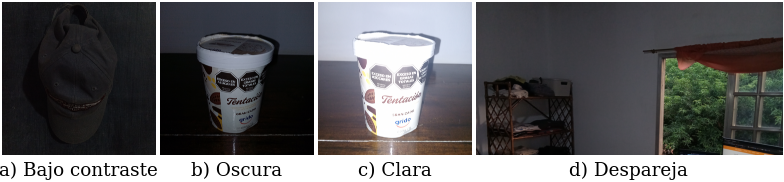

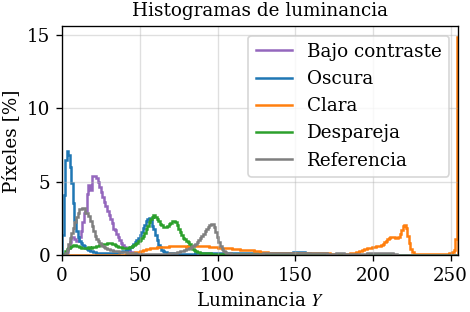

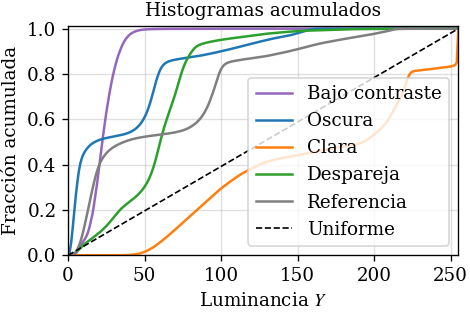

In [11]:
# La de iluminación despareja es el doble de ancha (mitad superior de la foto)
fig, axs = plt.subplots(1, 4, figsize=(ancho(1.0), 3), gridspec_kw={"width_ratios": [1, 1, 1, 2]})
for ax, caso, letra in zip(axs, CASOS_TP, "abcd"):
    mostrar_img(ax, IMG[caso], caso, letra)
guardar(fig, "casos_imagenes")
plt.show()

# Histogramas de luminancia
fig, ax = plt.subplots(figsize=(ancho(0.6), 2.6))
for caso, img in IMG.items():
    h, bordes = np.histogram(luminancia(img), bins=256, range=(0, 1))
    ax.stairs(100 * h / h.sum(), 255 * bordes, label=caso, color=COLORES[caso], lw=1.5)
ax.set(xlabel="Luminancia $Y$", ylabel="Píxeles [%]", xlim=(0, 255), title="Histogramas de luminancia")
ax.grid(True)
ax.legend()
guardar(fig, "casos_histogramas")
plt.show()

# Histogramas acumulados (CDF): la ecualización global los lleva a la diagonal
fig, ax = plt.subplots(figsize=(ancho(0.6), 2.6))
for caso, img in IMG.items():
    h, bordes = np.histogram(luminancia(img), bins=256, range=(0, 1))
    ax.plot(255 * bordes[1:], np.cumsum(h) / h.sum(), label=caso, color=COLORES[caso], lw=1.5)
ax.plot([0, 255], [0, 1], "k--", lw=1, label="Uniforme")
ax.set(xlabel="Luminancia $Y$", ylabel="Fracción acumulada", xlim=(0, 255), ylim=(0, 1.01),
       title="Histogramas acumulados")
ax.grid(True)
ax.legend(loc="lower right")
guardar(fig, "casos_cdf")
plt.show()

**Qué mirar:**
- **Bajo contraste:** casi todos los píxeles deberían caer en pocos niveles, con una CDF que sube como un escalón.
- **Oscura y clara:** los histogramas tendrían que estar corridos hacia uno y otro extremo.
- **Clara:** pico en 255. Es el 10.8 % saturado que no se puede recuperar.
- **Despareja:** el histograma debería tener dos poblaciones, el interior oscuro y la ventana.

## 3. Enfoque 1: ecualización independiente de R, G y B

Cada canal recibe su propia curva $T_R$, $T_G$, $T_B$, calculada con su propio histograma. Si las curvas son distintas, la proporción entre canales cambia en cada píxel, y con ella el color.

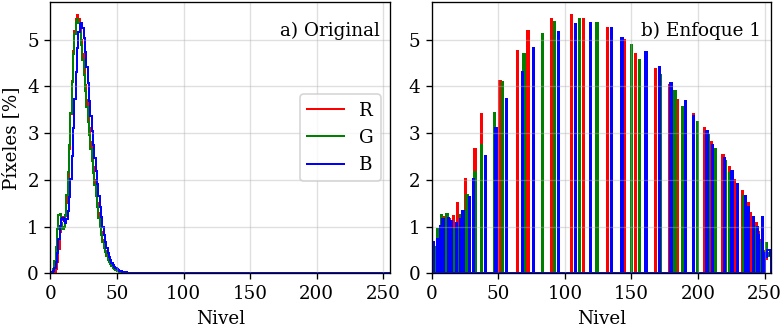

In [12]:
original = IMG["Bajo contraste"]
enfoque1 = ecualizar_por_canal(original, eq_global)

fig, axs = plt.subplots(1, 2, figsize=(ancho(1), 2.75))
for ax, img, titulo, letra in zip(axs, [original, enfoque1], ["Original", "Enfoque 1"], "ab"):
    for i, nombre in enumerate(["red", "green", "blue"]):
        h, b = np.histogram(img[..., i], bins=256, range=(0, 1))
        ax.stairs(100 * h / h.sum(), 255 * b, color=nombre, lw=1.2, label="RGB"[i])
    ax.set(xlabel="Nivel", xlim=(0, 255))
    ax.grid(True)
    etiquetar(ax, letra, titulo)
axs[0].set_ylabel("Píxeles [%]")
axs[0].legend(loc="center right")
guardar(fig, "enfoque1_histogramas_rgb")
plt.show()

## 4. Enfoque 2: ecualización de la luminancia

Se ecualiza solo $Y$ (YIQ) y se conservan $I$ y $Q$, igual que en `7_Histograma`: `RGB → YIQ → ecualizar Y → Y'IQ → RGB`.

Píxeles fuera de gama al volver a RGB: 1.12 %


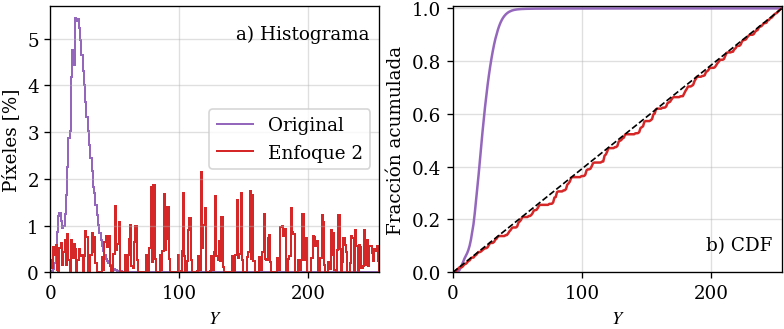

In [13]:
enfoque2, fuera_e2 = ecualizar_luminancia(original, eq_global, "YIQ")
print(f"Píxeles fuera de gama al volver a RGB: {100 * fuera_e2:.2f} %")

y_orig, y_e2 = luminancia(original), luminancia(enfoque2)
fig, axs = plt.subplots(1, 2, figsize=(ancho(1.0), 2.75))
for y, nombre, c in [(y_orig, "Original", "tab:purple"), (y_e2, "Enfoque 2", "tab:red")]:
    h, b = np.histogram(y, bins=256, range=(0, 1))
    axs[0].stairs(100 * h / h.sum(), 255 * b, color=c, lw=1.2, label=nombre)
    axs[1].plot(255 * b[1:], np.cumsum(h) / h.sum(), color=c, lw=1.5, label=nombre)
axs[1].plot([0, 255], [0, 1], "k--", lw=1)
axs[0].set(xlabel="$Y$", ylabel="Píxeles [%]", xlim=(0, 255))
axs[1].set(xlabel="$Y$", ylabel="Fracción acumulada", xlim=(0, 255), ylim=(0, 1.01))
axs[0].legend(loc="center right")
for ax, letra in zip(axs, "ab"):
    ax.grid(True)
etiquetar(axs[0], "a", "Histograma")
etiquetar(axs[1], "b", "CDF", abajo=True)
guardar(fig, "enfoque2_histograma_y")
plt.show()

### ¿Importa qué espacio de luminancia se usa?

Se repite el enfoque 2 en los cuatro espacios. Dos cosas a tener en cuenta:
- **YIQ y YCbCr** calculan $Y$ con los mismos coeficientes, así que deberían dar resultados prácticamente idénticos.
- **YIQ frente a HSV.** "Conservar el color" no significa lo mismo en los dos:
  - **YIQ** mantiene fijos $I$ y $Q$, y como $R - G$ y $B - G$ dependen solo de $I$ y $Q$, conserva las **diferencias** entre canales.
  - **HSV** escala R, G y B en la misma proporción, así que conserva los **cocientes**. Es lo que pasaría con más luz real, y por eso al aclarar aumenta la croma absoluta.

Diferencia máxima YIQ vs YCbCr: 0.01 niveles


,% fuera de gama,Contraste RMS,C* medio,% C* > 5,Δh medio [°]
Espacio,,,,,
YIQ,1.12,73.23,1.59,0.07,2.02
YCbCr,1.12,73.23,1.59,0.07,2.02
HSV,0.00,69.67,7.74,73.55,2.42
Lab,1.12,71.79,1.82,0.19,1.13


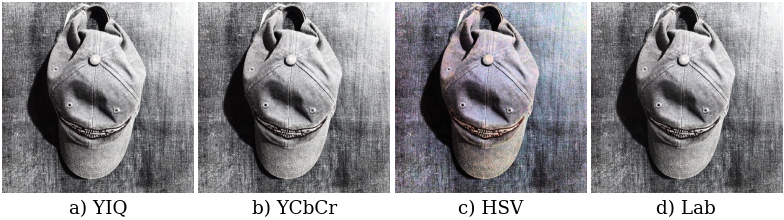

In [14]:
ESPACIOS = ["YIQ", "YCbCr", "HSV", "Lab"]
resultado_espacio, filas = {}, []
for espacio in ESPACIOS:
    img_eq, fuera = ecualizar_luminancia(original, eq_global, espacio)
    resultado_espacio[espacio] = img_eq
    filas.append({"Espacio": espacio, "% fuera de gama": 100 * fuera,
                  "Contraste RMS": contraste_rms(luminancia(img_eq)),
                  **metricas_color(original, img_eq)})

dif = 255 * np.abs(resultado_espacio["YIQ"] - resultado_espacio["YCbCr"]).max()
print(f"Diferencia máxima YIQ vs YCbCr: {dif:.2f} niveles")
display(pd.DataFrame(filas).set_index("Espacio").round(2))

fig, axs = plt.subplots(1, 4, figsize=(ancho(1.0), 3))
for ax, espacio, letra in zip(axs, ESPACIOS, "abcd"):
    mostrar_img(ax, resultado_espacio[espacio], espacio, letra)
guardar(fig, "enfoque2_espacios")
plt.show()

## 5. Comparación de los dos enfoques

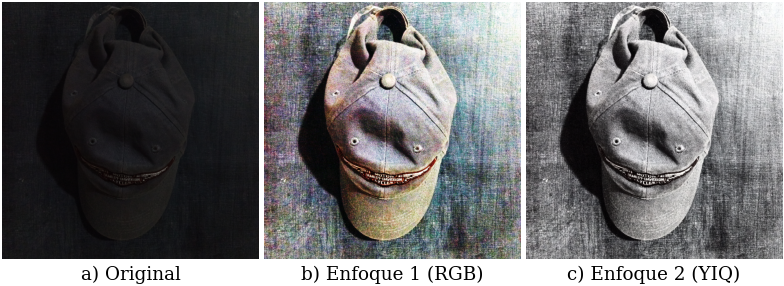

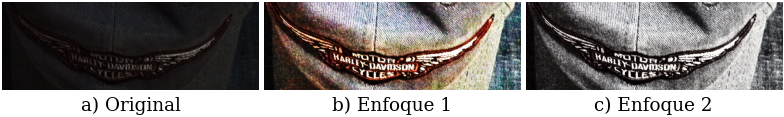

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(ancho(1.0), 3.5))
for ax, img, titulo, letra in zip(axs, [original, enfoque1, enfoque2],
                                  ["Original", "Enfoque 1 (RGB)", "Enfoque 2 (YIQ)"], "abc"):
    mostrar_img(ax, img, titulo, letra)
guardar(fig, "enfoques_comparacion")
plt.show()

# Detalle del logo: el único elemento con color de la escena
LOGO = (0.58, 0.73, 0.28, 0.72)
fig, axs = plt.subplots(1, 3, figsize=(ancho(1.0), 2))
for ax, img, titulo, letra in zip(axs, [original, enfoque1, enfoque2],
                                  ["Original", "Enfoque 1", "Enfoque 2"], "abc"):
    mostrar_img(ax, recortar(img, LOGO), titulo, letra)
guardar(fig, "enfoques_detalle_logo")
plt.show()

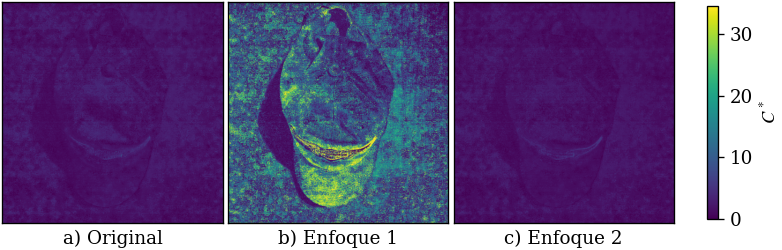

,Media R,Media G,Media B,R/G,B/G,R−G,B−G
Original,22.98,22.38,24.34,1.03,1.09,0.60,1.96
Enfoque 1,131.05,130.77,131.03,1.00,1.00,0.27,0.26
Enfoque 2 (YIQ),131.10,130.51,132.46,1.00,1.01,0.59,1.95
Enfoque 2 (HSV),120.63,118.53,128.23,1.02,1.08,2.10,9.70


In [16]:
# Mapas de croma: dónde aparece color que antes no había
cromas = [croma_y_tono(img)[0] for img in (original, enfoque1, enfoque2)]
vmax = np.percentile(cromas[1], 99)
fig, axs = plt.subplots(1, 3, figsize=(ancho(1.0), 2.3))
for ax, c, titulo, letra in zip(axs, cromas, ["Original", "Enfoque 1", "Enfoque 2"], "abc"):
    im = ax.imshow(c, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f"{letra}) {titulo}")
fig.colorbar(im, ax=axs, label="$C^*$", shrink=0.8)
guardar(fig, "enfoques_croma")
plt.show()

# Balance de color: medias por canal, cocientes y diferencias
pd.DataFrame({"Original": balance(original), "Enfoque 1": balance(enfoque1),
              "Enfoque 2 (YIQ)": balance(enfoque2),
              "Enfoque 2 (HSV)": balance(resultado_espacio["HSV"])}).T.round(2)

In [17]:
# Los dos enfoques en las cuatro imágenes (ecualización global)
filas = []
for caso in CASOS_TP:
    img = IMG[caso]
    e1 = ecualizar_por_canal(img, eq_global)
    e2, fuera = ecualizar_luminancia(img, eq_global, "YIQ")
    for nombre, res, fg in [("Original", img, 0.0), ("Enfoque 1", e1, 0.0), ("Enfoque 2", e2, fuera)]:
        filas.append({"Caso": caso, "Versión": nombre, **metricas_color(img, res),
                      **{k: v for k, v in balance(res).items() if not k.startswith("Media")},
                      "% fuera de gama": 100 * fg})
tabla_enfoques = pd.DataFrame(filas).set_index(["Caso", "Versión"])
tabla_enfoques.round(2)

C* medio  % C* > 5  Δh medio [°]   R/G   B/G   R−G  \
Caso           Versión                                                         
Bajo contraste Original       1.83      0.20          0.00  1.03  1.09  0.60   
               Enfoque 1     10.26     65.95         24.21  1.00  1.00  0.27   
               Enfoque 2      1.59      0.07          2.02  1.00  1.01  0.59   
Oscura         Original       3.74     36.84          0.00  0.98  1.10 -0.89   
               Enfoque 1      9.13     56.40         28.02  1.01  0.99  0.98   
               Enfoque 2      3.26     27.69          9.29  0.99  1.03 -0.89   
Clara          Original       7.71     75.94          0.00  1.02  1.04  2.89   
               Enfoque 1      5.84     41.72         34.45  1.00  1.01  0.63   
               Enfoque 2      7.86     75.18          2.50  1.02  1.06  2.88   
Despareja      Original       6.10     28.20          0.00  1.01  0.98  0.38   
               Enfoque 1     12.50     76.96         20.37  1.00  1.01  0.05   
               Enfoque 2      5.35     25.09          2.86  1.00  0.99  0.18   

                           B−G  % fuera de gama  
Caso           Versión                           
Bajo contraste Original   1.96             0.00  
               Enfoque 1  0.26             0.00  
               Enfoque 2  1.95             1.12  
Oscura         Original   3.76             0.00  
               Enfoque 1 -0.97             0.00  
               Enfoque 2  3.38             4.46  
Clara          Original   6.95             0.00  
               Enfoque 1  0.88             0.00  
               Enfoque 2  7.26             5.99  
Despareja      Original  -1.43             0.00  
               Enfoque 1  1.19             0.00  
               Enfoque 2 -1.29             4.49

### Preguntas

**1. Comparar los dos resultados. ¿Qué artefactos de color se observan en el primer enfoque? ¿Por qué ocurren?**

*Qué mirar:*
- **Mapa de croma.** Fijate si en el enfoque 1 aparece color donde la gorra y el fondo eran grises.
- **Detalle del logo.** Si cambió el tono del bordado.
- **Medias por canal.** Si los tres canales terminan con la misma media, el enfoque 1 hizo un "balance de blancos" sin que nadie se lo pidiera.
- **Las otras imágenes.** Si Δh es grande en las de color.

> **Respuesta:** En el primer enfoque lo que hace es "inventarse" colores donde no los habia. Entonces tratando de balancear los blancos se expande el histograma agregando cosas donde antes no las habia.

**2. Explicar por qué el segundo enfoque preserva el balance de color original mientras mejora el contraste de manera efectiva.**

*Qué mirar:*
- **Tabla de balance.** Qué se conserva con YIQ, ¿los cocientes o las diferencias? ¿Y con HSV?
- **Precisión de "preserva".** Cuánto se recortó por quedar fuera de gama, y en qué imágenes es mayor. ¿Lo preserva *exactamente*?
- **Elección del espacio.** ¿Cuál de las dos formas de "conservar el color" tiene más sentido para esta tarea?

> **Respuesta:** Por que al ecualizar unicamente el canal de crominancia lo que hace es distribuir realmente las diferencias que hay entre la variación de pixeles, sin inventarse nada, en vez de tocar colores toca la iluminación.

## 6. Tipos de ecualización según el histograma

Con el enfoque 2 (YIQ) se aplican el estiramiento lineal, la ecualización global y CLAHE (`clip = 0.01`) a las cuatro imágenes.

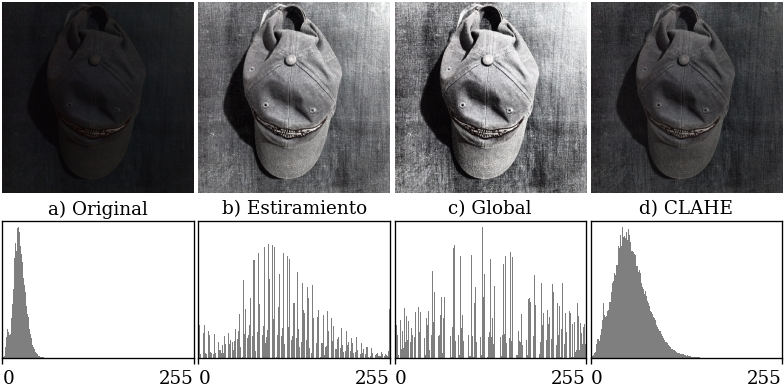

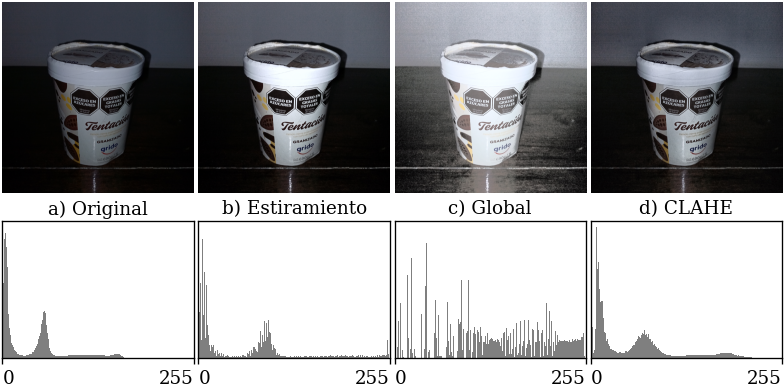

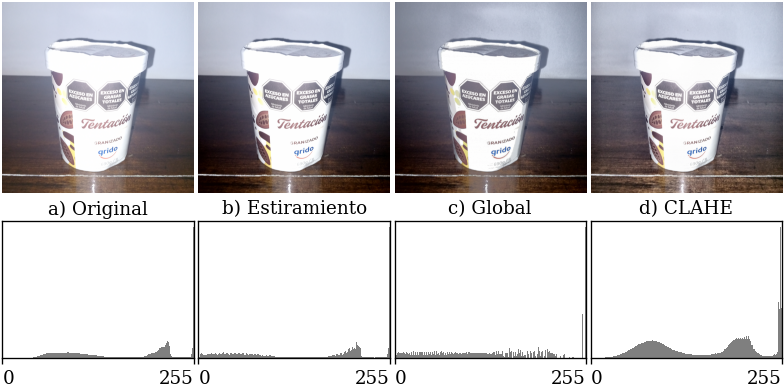

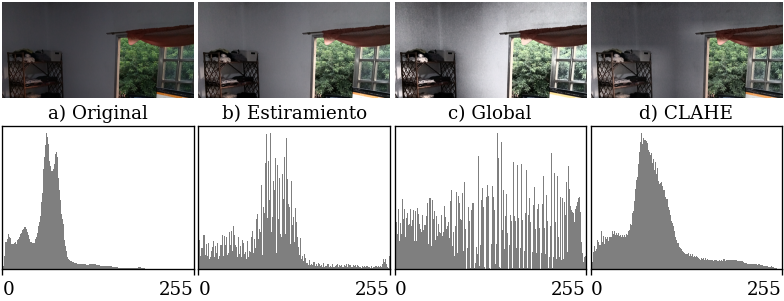

Contraste RMS  Entropía [bits]  Niveles usados  \
Caso           Método                                                         
Bajo contraste Original               8.46             5.08             184   
               Estiramiento          52.77             6.96             245   
               Global                73.23             7.09             237   
               CLAHE                 23.30             6.54             254   
Oscura         Original              40.20             5.95             244   
               Estiramiento          66.24             6.48             256   
               Global                71.68             7.26             252   
               CLAHE                 52.46             6.73             255   
Clara          Original              70.77             6.80             239   
               Estiramiento          86.92             7.01             256   
               Global                77.52             7.29             244   
               CLAHE                 70.32             7.30             254   
Despareja      Original              27.74             6.53             253   
               Estiramiento          45.69             7.13             256   
               Global                73.82             7.66             256   
               CLAHE                 42.49             7.22             255   

                             % saturados      Ruido  Ruido / original  \
Caso           Método                                                   
Bajo contraste Original             0.00   3.090000              1.00   
               Estiramiento         1.39  20.129999              6.51   
               Global               0.06  30.540001              9.88   
               CLAHE                0.00  10.460000              3.38   
Oscura         Original             0.24   3.210000              1.00   
               Estiramiento         2.38   5.310000              1.65   
               Global               0.00  14.670000              4.57   
               CLAHE                0.00   8.600000              2.68   
Clara          Original            10.78   1.710000              1.00   
               Estiramiento        10.76   2.110000              1.23   
               Global              10.78   4.160000              2.43   
               CLAHE                0.99   4.440000              2.60   
Despareja      Original             0.00   2.570000              1.00   
               Estiramiento         0.92   4.420000              1.72   
               Global               0.03  14.500000              5.65   
               CLAHE                0.00   6.400000              2.49   

                             Δμ obj-fondo    d′  
Caso           Método                            
Bajo contraste Original              2.16  0.36  
               Estiramiento         13.47  0.35  
               Global               13.16  0.25  
               CLAHE                12.89  0.68  
Oscura         Original               NaN   NaN  
               Estiramiento           NaN   NaN  
               Global                 NaN   NaN  
               CLAHE                  NaN   NaN  
Clara          Original               NaN   NaN  
               Estiramiento           NaN   NaN  
               Global                 NaN   NaN  
               CLAHE                  NaN   NaN  
Despareja      Original               NaN   NaN  
               Estiramiento           NaN   NaN  
               Global                 NaN   NaN  
               CLAHE                  NaN   NaN

In [18]:
SLUG = {"Bajo contraste": "bajo_contraste", "Oscura": "oscura", "Clara": "clara", "Despareja": "despareja"}
filas = []
for caso in CASOS_TP:
    img, cfg = IMG[caso], CASOS[caso]
    versiones = {"Original": img}
    for nombre, metodo in METODOS.items():
        versiones[nombre], _ = ecualizar_luminancia(img, metodo, "YIQ")

    # Alto calculado para que las imágenes ocupen todo el ancho de su columna
    alto_img = (ancho(1.0) / 4 - 0.1) * img.shape[0] / img.shape[1]
    fig, axs = plt.subplots(2, 4, figsize=(ancho(1.0), alto_img + 1.8),
                            gridspec_kw={"height_ratios": [alto_img, 1.0]})
    ruido_original = ruido(luminancia(img), cfg["zona_plana"])
    for j, (nombre, res) in enumerate(versiones.items()):
        y = luminancia(res)
        mostrar_img(axs[0, j], res, nombre, 'abcd'[j])
        h, b = np.histogram(y, bins=256, range=(0, 1))
        axs[1, j].stairs(100 * h / h.sum(), 255 * b, fill=True, color="tab:gray")
        axs[1, j].set(xlim=(0, 255), xticks=[0, 255], yticks=[])
        # "0" alineado a la izquierda y "255" a la derecha, para que no se toquen entre columnas
        for etiqueta, alineacion in zip(axs[1, j].get_xticklabels(), ["left", "right"]):
            etiqueta.set_horizontalalignment(alineacion)
        fila = {"Caso": caso, "Método": nombre, "Contraste RMS": contraste_rms(y),
                "Entropía [bits]": entropia(y), "Niveles usados": niveles_usados(y),
                "% saturados": saturados(y), "Ruido": ruido(y, cfg["zona_plana"])}
        fila["Ruido / original"] = fila["Ruido"] / ruido_original
        if "objeto" in cfg:
            fila["Δμ obj-fondo"], fila["d′"] = separacion(y, cfg["objeto"], cfg["zona_plana"])
        filas.append(fila)
    guardar(fig, f"metodos_{SLUG[caso]}")
    plt.show()

tabla_metodos = pd.DataFrame(filas).set_index(["Caso", "Método"])
tabla_metodos.round(2)

### Verificación: ¿la ecualización crea información?

En la tabla anterior, la entropía y los niveles usados **suben** después de ecualizar, y eso parece contradecir que la ecualización no crea información. La explicación está en cómo se obtiene $Y$:

- **Imagen de un solo canal de 8 bits** (por ejemplo, con `cv2.equalizeHist`): la curva actúa sobre los mismos 256 niveles que mide el histograma. Puede separar o juntar niveles, pero no crear valores nuevos, así que la entropía no puede subir.
- **Este caso:** $Y$ se calcula a partir de tres canales de 8 bits, así que tiene resolución más fina que 256 niveles (miles de valores distintos). La ecualización estira diferencias que antes caían en el mismo nivel y ahora caen en niveles distintos. La información ya estaba en los datos RGB; el histograma de 256 niveles la subestimaba.

Se comparan los dos casos para cada imagen.

In [19]:
filas = []
for caso in CASOS_TP:
    y = luminancia(IMG[caso])
    y8 = np.round(255 * y).astype(np.uint8)          # Y llevado a 8 bits
    y8_eq = cv2.equalizeHist(y8) / 255               # ecualización sobre los mismos 256 niveles
    y_eq = eq_global(y)                              # ecualización sobre Y con resolución completa
    filas.append({"Caso": caso,
                  "Valores distintos de Y": np.unique(np.round(16 * 255 * y)).size,  # a 1/16 de nivel
                  "Entropía original": entropia(y8 / 255),
                  "Entropía (8 bits)": entropia(y8_eq), "Entropía (Y completa)": entropia(y_eq),
                  "Niveles original": niveles_usados(y8 / 255),
                  "Niveles (8 bits)": niveles_usados(y8_eq), "Niveles (Y completa)": niveles_usados(y_eq)})
pd.DataFrame(filas).set_index("Caso").round(3)

,Valores distintos de Y,Entropía original,Entropía (8 bits),Entropía (Y completa),Niveles original,Niveles (8 bits),Niveles (Y completa)
Caso,,,,,,,
Bajo contraste,1796,5.055,5.021,7.090,184,44,237
Oscura,2796,5.928,5.680,7.265,244,91,252
Clara,3485,6.889,6.666,7.297,239,146,244
Despareja,3682,6.526,6.355,7.674,253,103,256


### Efecto del `clip` de CLAHE

El `clip` limita cuánto puede crecer la pendiente de la curva en cada zona. Si es bajo, el efecto es suave; si es alto, cada zona se ecualiza casi por completo y el ruido crece. La figura muestra un detalle de la gorra y el fondo con distintos valores.

Contraste RMS  Entropía [bits]  Ruido / original
Caso           clip                                                   
Bajo contraste 0.005          14.59             5.48              1.73
               0.010          23.30             6.54              3.38
               0.030          50.61             7.65              8.99
Oscura         0.005          50.09             6.19              1.34
               0.010          52.46             6.73              2.68
               0.030          57.09             7.42              7.55
Clara          0.005          81.83             5.87              0.62
               0.010          70.32             7.30              2.60
               0.030          60.88             7.45              7.20
Despareja      0.005          34.18             6.73              1.28
               0.010          42.49             7.22              2.49
               0.030          50.77             7.62              6.77

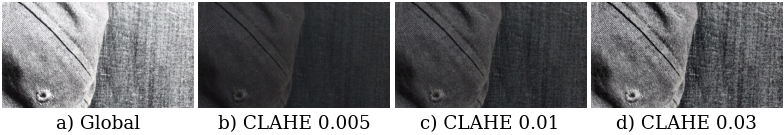

In [20]:
CLIPS = [0.005, 0.01, 0.03]
filas = []
for caso in CASOS_TP:
    img, cfg = IMG[caso], CASOS[caso]
    ruido_original = ruido(luminancia(img), cfg["zona_plana"])
    for clip in CLIPS:
        res, _ = ecualizar_luminancia(img, lambda c: eq_clahe(c, clip), "YIQ")
        y = luminancia(res)
        filas.append({"Caso": caso, "clip": clip, "Contraste RMS": contraste_rms(y),
                      "Entropía [bits]": entropia(y),
                      "Ruido / original": ruido(y, cfg["zona_plana"]) / ruido_original})
display(pd.DataFrame(filas).set_index(["Caso", "clip"]).round(2))

DETALLE = (0.35, 0.60, 0.50, 0.95)   # copa de la gorra y fondo
img = IMG["Bajo contraste"]
versiones = {"Global": ecualizar_luminancia(img, eq_global, "YIQ")[0]}
for clip in CLIPS:
    versiones[f"CLAHE {clip}"] = ecualizar_luminancia(img, lambda c: eq_clahe(c, clip), "YIQ")[0]
fig, axs = plt.subplots(1, 4, figsize=(ancho(1.0), 2))
for ax, (nombre, res), letra in zip(axs, versiones.items(), "abcd"):
    mostrar_img(ax, recortar(res, DETALLE), nombre, letra)
guardar(fig, "clahe_clip_bajo_contraste")
plt.show()

### Verificación: ¿CLAHE recupera las zonas quemadas?

En la imagen clara, CLAHE baja el porcentaje de píxeles saturados del 10.8 % a cerca del 1 %. Hay que comprobar si recuperó detalle o solo movió el valor. Para eso se miran los píxeles que estaban en 255 en la original:
- **Valor de salida:** a qué nivel quedaron después de CLAHE.
- **Detalle interno:** desvío del residuo de alta frecuencia dentro de la zona saturada, sin contar los bordes. Si sigue cerca de cero, no hay detalle.

In [21]:
y = luminancia(IMG["Clara"])
saturado = np.round(255 * y) == 255
interior = cv2.erode(saturado.astype(np.uint8), np.ones((15, 15), np.uint8)).astype(bool)

def detalle(y_img):
    residuo = y_img - cv2.GaussianBlur(y_img.astype(np.float32), (0, 0), 2)
    return 255 * residuo[interior].std()

y_clahe = luminancia(ecualizar_luminancia(IMG["Clara"], eq_clahe, "YIQ")[0])
print(f"Píxeles saturados en la original: {100 * saturado.mean():.2f} %")
print(f"Después de CLAHE quedan entre {255 * y_clahe[saturado].min():.1f} y "
      f"{255 * y_clahe[saturado].max():.1f} (mediana {255 * np.median(y_clahe[saturado]):.1f})")
print(f"Detalle interno: original {detalle(y):.3f} niveles | CLAHE {detalle(y_clahe):.3f} niveles")

Píxeles saturados en la original: 10.78 %
Después de CLAHE quedan entre 249.7 y 255.0 (mediana 253.3)
Detalle interno: original 0.042 niveles | CLAHE 0.327 niveles


### Exploración interactiva

Se trabaja sobre versiones reducidas (800 px) para que la respuesta sea inmediata. **No se usa para las métricas.**

In [22]:
PREVIA = {}
for caso, img in IMG.items():
    escala = 800 / max(img.shape[:2])
    PREVIA[caso] = cv2.resize(img, None, fx=escala, fy=escala, interpolation=cv2.INTER_AREA)


def explorar(caso, metodo, clip, zona):
    img = PREVIA[caso]
    if metodo == "CLAHE":
        lado = int(max(img.shape[:2]) * zona)
        funcion = lambda c: eq_clahe(c, clip, lado)
    else:
        funcion = METODOS[metodo]
    res, _ = ecualizar_luminancia(img, funcion, "YIQ")
    fig, axs = plt.subplots(1, 3, figsize=(13, 4))
    mostrar_img(axs[0], img, "Original")
    mostrar_img(axs[1], res, metodo)
    for im, nombre in [(img, "Original"), (res, metodo)]:
        h, b = np.histogram(luminancia(im), bins=256, range=(0, 1))
        axs[2].stairs(100 * h / h.sum(), 255 * b, label=nombre)
    axs[2].set(xlabel="$Y$", ylabel="Píxeles [%]", xlim=(0, 255))
    axs[2].legend()
    plt.show()


widgets.interact(
    explorar,
    caso=widgets.Dropdown(options=list(IMG), value="Despareja", description="Imagen"),
    metodo=widgets.Dropdown(options=list(METODOS), value="CLAHE", description="Método"),
    clip=widgets.FloatLogSlider(value=0.01, base=10, min=-3, max=-1, step=0.1,
                                description="clip", continuous_update=False),
    zona=widgets.SelectionSlider(options=[("1/16", 1 / 16), ("1/8", 1 / 8), ("1/4", 1 / 4)],
                                 value=1 / 8, description="zona", continuous_update=False),
);

interactive(children=(Dropdown(description='Imagen', index=3, options=('Bajo contraste', 'Oscura', 'Clara', 'D…

### Pregunta

**3. Para el enfoque adecuado, analizar los efectos de distintos tipos de ecualización. ¿El enfoque depende de qué? (probar varias imágenes, con histogramas concentrados en distintos rangos).**

*Qué mirar:*
- **Bajo contraste.** Cuánto aumenta Δμ entre objeto y fondo, y si d′ aumenta en la misma medida. Si Δμ crece pero d′ no, la ecualización hizo *visible* una diferencia que ya existía, sin crear separabilidad.
- **Oscura.** Cuánto se amplifica el ruido con la ecualización global y cuánto con CLAHE.
- **Clara.** Qué pasa con el 10.8 % saturado (ver la verificación de las zonas quemadas).
- **Despareja.** Si la ecualización global puede mejorar a la vez la ventana y el interior, y qué hace CLAHE.
- **En todas.** Qué relación hay entre la ganancia de contraste (RMS) y la amplificación del ruido.

> **Respuesta:** Por lo que llego a notar, jugando con los valores lo mejor que se puede obtener es la variación del clip para el CLAHE, para la Global se ve que blanquea muchisimo la foto, mientras que el estiramiento pareciera darle un poco mas de brillo nomas. El CLAHE con un clip muy alto qeuma algunas zonas, por lo general para el deslizador que se uso con un valor entre la mitad y el valor mínimo mejora mucho cualquier foto.

## 7. Bitácora

| Bloque | Opción elegida | Por qué | Alternativa descartada | Problema que tenía | Criterio |
|---|---|---|---|---|---|
| Imagen de bajo contraste | `gorra.jpeg` | El 98 % de los píxeles cae en 39 niveles (contraste RMS 8.5); además, objeto y fondo tienen brillos similares | `ventana.jpeg`, `arbol.jpeg` | Ventana: la niebla cubre solo el centro (RMS 42.7). Árbol: es de alto contraste (contraluz) | Métrica |
| Imagen clara | `clara_nueva.jpeg` (ISO 800, EV +2) | Mediana 193, 53 % de píxeles claros | `clara_ev+2.jpeg` (ISO 100, EV +2) | Mediana 70, solo 13.5 % claros: la mesa oscura ocupaba el cuadro y el +2 rindió +1.2 EV | Métrica |
| Iluminación despareja | `habitacion_superior.png` | Conserva la ventana y el interior en sombra | Imagen completa | Aparecía una persona | — |
| Espacio del enfoque 2 | YIQ | _(completar)_ | YCbCr, HSV, Lab | _(completar)_ | _(completar)_ |
| Método por tipo de imagen | _(completar)_ | | | | |

Las imágenes descartadas no se incluyen en el repositorio.

**Limitaciones de la adquisición:**
- **Oscura y clara no son la misma escena:** cambiaron el encuadre y el ISO (100 contra 800). La comparación entre las dos no aísla una sola variable.
- **Las fotos son JPEG de 8 bits.** Los artefactos de compresión pueden amplificarse al ecualizar.
- **Ajustes automáticos:** los EXIF registran balance de blancos automático y medición promedio.
- **La gorra se tomó con ISO 400,** así que tiene más ruido de partida.